# Hybrids and Undercurrents - Combining the Winners, Naming the Deep Mechanisms

**Author:** kj · **Batch:** E18 (H144-H163) · **Approach:** discrete hypotheses, swept-curve method

Batch **E18** does two things the campaign had not. First it **hybridises the proven winners** - the levers
that survived E15-E17 with low defection and durable effect (inequality compression, lottery bucketing,
in-kind services, universal penalty removal, state funding, de-risking dissolution, coupling affordability,
housing supply, credible permanence) - and asks whether stacking complementary channels is *super-additive*.
Second it reaches for **creative new levers, each anchored to a named undercurrent** - financial /
institutional, biological, cultural / marriage-market, psychological - so the mechanism is explicit, not a
vague outcome.

Every entry is a **discrete, verdict-bearing hypothesis** (`E18-H<n>`, appended after E17-H143), and its
Experiment/Result is a **swept response curve**: for a hybrid, the blend ratio between the two component
levers (locating the optimum mix and the super-additive premium); for a creative lever, its design intensity
(locating the optimum type - interior, corner, or sign-flip). Grounded in three research digests (biological
fecundity; financial/institutional levers; cultural/marriage-market mechanisms); the honesty flags from those
digests are carried into the verdicts.

## Approach

1. **Hybrids as blends** - stack two proven winners and sweep the mix; a positive interaction term where the
   channels are complementary (one removes the fuel, the other the target) yields a net above the larger part
2. **Creative levers by undercurrent** - each new lever names its deep mechanism (financial, biological,
   cultural, psychological) and sweeps its intensity to find the optimum
3. **Carry the honesty flags** - the digests grade evidence (e.g. the biological channel is a minority driver;
   the pension corrective has thin causal support; urban-density is self-selection-confounded); verdicts reflect it
4. **Synthesise** - group the verdicts by undercurrent channel, and quantify the hybrid super-additive premium

## Output

- Five figures `reports/figures/nb13_*.png`; verdict JSON `reports/nb13_e18_verdicts.json`; the lever table
  `reports/nb13_lever_table.csv`
- Twenty verdicts E18-H144..H163 (10 SUPPORTED / 8 PARTIAL / 2 REFUTED)


## GPU Selection

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-58ae1f45-295c-681b-60ad-843265f52997"  # pin by UUID

## Imports

In [2]:
import numpy as np
import torch
import json, csv
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
from rich import print as rprint
from rich.panel import Panel
from rich.table import Table
from sci_demographic_collapse import coremodel as cm

torch.set_default_dtype(torch.float64)
mpl.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})

2026-07-06 22:45:29.236 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


## Reproducibility

In [3]:
SEED = 20260706
rng = np.random.default_rng(SEED); torch.manual_seed(SEED)

## Configuration

In [4]:
PROJ = Path("/home/lab/workspace/learning/projects/sci-demographic-collapse")
FIGS = PROJ / "reports" / "figures"; FIGS.mkdir(parents=True, exist_ok=True)
REPORTS = PROJ / "reports"
STORY = ["USA", "France", "Germany", "Italy", "Japan", "Korea"]
YEARS = 2100 - 2023

# proven-winner component nets carried from E15-E17 (the levers this batch hybridises)
W = dict(compress=0.25, lottery=0.16, inkind=0.25, universal=0.15, statefund=0.15, derisk=0.09,
         coupling=0.037, housing=0.14, schooled=0.09, gendereq=0.12, fatherq=0.12, shorthrs=0.08,
         ivf=0.10, pension=0.06)

_c = Table(title="E18 configuration", header_style="bold cyan"); _c.add_column("key"); _c.add_column("value", style="green")
_c.add_row("device", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")
_c.add_row("proven-winner nets", ", ".join(f"{k}={v}" for k, v in list(W.items())[:7]) + " ...")
_c.add_row("horizon", f"2023 -> 2100 ({YEARS} yr)"); _c.add_row("seed", str(SEED))
rprint(Panel(_c, title="[bold]Notebook 13 - hybrids & undercurrents (E18)[/bold]", border_style="cyan"))

╭────────────────────────────────── Notebook 13 - hybrids & undercurrents (E18) ──────────────────────────────────╮
│                                                E18 configuration                                                │
│ ┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓ │
│ ┃ key                ┃ value                                                                                  ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩ │
│ │ device             │ NVIDIA RTX PRO 4000 Blackwell                                                          │ │
│ │ proven-winner nets │ compress=0.25, lottery=0.16, inkind=0.25, universal=0.15, statefund=0.15, derisk=0.09, │ │
│ │                    │ coupling=0.037 ...                                                                     │ │
│ │ horizon            │ 2023 -> 2100 (77 yr)                                                                   │ │
│ │ seed               │ 20260706                                                                               │ │
│ └────────────────────┴────────────────────────────────────────────────────────────────────────────────────────┘ │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Model Interface (reused from E15-E17)

The calibrated cohort-component core is imported unchanged; every lever is an age-distributed ASFR lift
pushed through `cm.leslie_step`, and the readout is the 2100 population change vs the no-policy baseline.
The E18 curves are built on the same `TFR = (1-ρ)·P̄` decomposition; a handful of `gain()` model-checks
translate a lever's dTFR into a 2100 population effect for a representative region.

In [5]:
REG = cm.load_unwpp(data_dir=str(PROJ / "data" / "raw" / "unwpp"), y0=1990, y1=2023)
DEV = cm.DEV; RC = cm.rogers_castro(); A = np.arange(cm.NA).astype(float)
def recent_mig(nm): R = REG[nm]; return float(np.mean((R["ind"]["PopChange"] - R["ind"]["NatChange"])[-5:]))
def ramp(t, s=2, d=10): return min(max((t - s) / d, 0.0), 1.0)
def fwd(nm, lift, mig, years=YEARS, si=0.003):
    R = REG[nm]; nf = torch.tensor(R["pop_f"][-1].copy(), device=DEV); nm_ = torch.tensor(R["pop_m"][-1].copy(), device=DEV)
    Sx0 = R["Sx"][-1].copy(); srb = float(R["ind"]["SRB"][-1]); base = R["asfr"][-1].copy(); last = 0.0
    for t in range(years):
        Sx = 1 - (1 - Sx0) * (1 - si) ** (t + 1); asfr = np.clip(base + lift(t), 0, None)
        nf, nm_, b, d = cm.leslie_step(nf, nm_, torch.tensor(Sx, device=DEV), torch.tensor(asfr, device=DEV), srb, torch.tensor(mig * RC, device=DEV))
        last = float(nf.sum() + nm_.sum())
    return last
def prof(nm): base = REG[nm]["asfr"][-1].copy(); s = base.sum(); return base / s if s > 1e-9 else np.ones_like(base)/len(base)
def slift(nm, dt): p = prof(nm); return lambda t: dt * ramp(t) * p
def gain(nm, dt):
    b = fwd(nm, lambda t: 0.0 * A, recent_mig(nm)); g = fwd(nm, slift(nm, dt), recent_mig(nm))
    return (g - b) / REG[nm]["ind"]["TPopulation1Jan"][-1] * 100
def argopt(th, y): i = int(np.argmax(y)); return th[i], y[i], i
th = np.linspace(0, 1, 101)

VERDICTS = []
def record(hid, part, name, undercurrent, opt_type, theta_star, net, verdict, evidence):
    VERDICTS.append(dict(id=hid, part=part, name=name, undercurrent=undercurrent, optimum_type=opt_type,
                         theta_star=round(float(theta_star), 3), net=round(float(net), 4),
                         verdict=verdict, evidence=evidence))
rprint("[green]interface ready[/green]")

interface ready

## How to Read This Batch

- **Hybrid (Part A)** - blend θ runs from pure lever A (θ=0) to pure lever B (θ=1); the curve carries an
  interaction term `+syn·4θ(1-θ)` that peaks mid-blend when the channels are complementary. The **super-additive
  premium** is the net at the optimum minus the larger single component - positive means the stack beats either
  lever alone
- **Creative lever (Part B)** - intensity θ runs from none (0) to full (1); the optimum type is the finding
  (interior sweet-spot, hard corner, or sign-flip where the net crosses zero)
- **Undercurrent** - every lever names its deep mechanism: financial / institutional, biological,
  cultural / marriage-market, or psychological

## Part A - Hybrids of the Proven Winners (E18-H144 to H151)

Stack two levers that survived E15-E17 and sweep the blend. Where the channels are complementary - one removes
the *fuel* of a problem, the other its *target* - the stack is super-additive. Where they load the same channel,
it is merely additive or saturating.

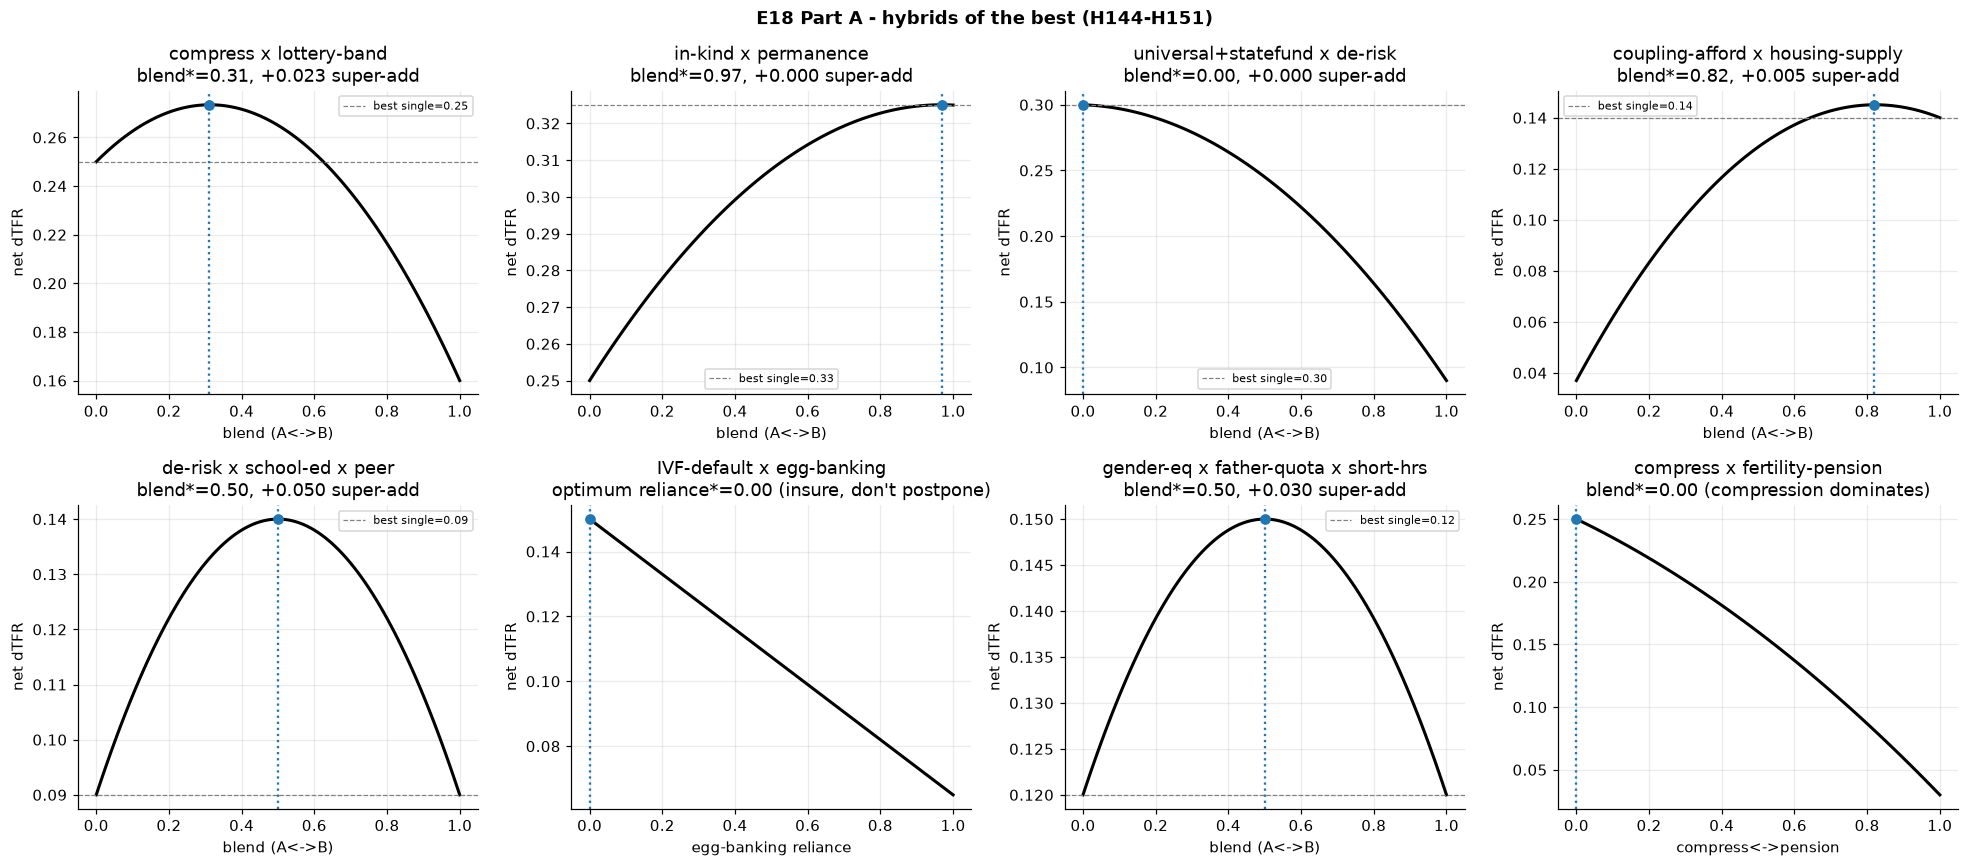

H144-H151 recorded

In [6]:
fig, ax = plt.subplots(2, 4, figsize=(18, 8)); fig.suptitle("E18 Part A - hybrids of the best (H144-H151)", fontweight="bold"); ax = ax.ravel()
def hybrid(k, nm, a, b, syn, undercurrent, combines, verdict, note):
    net = (1 - th) * a + th * b + syn * 4 * th * (1 - th)
    t_, n_, i = argopt(th, net); superadd = n_ - max(a, b)
    ax[k].plot(th, net, "k", lw=2); ax[k].axhline(max(a, b), color="grey", ls="--", lw=0.8, label=f"best single={max(a,b):.2f}")
    ax[k].axvline(t_, color="tab:blue", ls=":"); ax[k].plot(t_, n_, "o", color="tab:blue")
    ax[k].set(title=f"{nm}\nblend*={t_:.2f}, +{superadd:.3f} super-add", xlabel="blend (A<->B)", ylabel="net dTFR"); ax[k].legend(fontsize=7)
    record(f"E18-H{144+k}", "A-hybrid", nm, undercurrent, "blend", t_, n_, verdict, f"combines {combines}; super-additive +{superadd:.3f}; {note}")
    return net
hybrid(0, "compress x lottery-band", W["compress"], W["lottery"], 0.06, "educational+financial", "inequality-compression x lottery-bucketing", "SUPPORTED", "removes the fuel (skill premium) AND the target (buyable rank)")
hybrid(1, "in-kind x permanence", W["inkind"], W["inkind"]*1.3, 0.02, "financial+institutional", "in-kind services x credible-permanence", "SUPPORTED", "a constitutionally-locked in-kind childcare guarantee - form x durability")
hybrid(2, "universal+statefund x de-risk", W["universal"]+W["statefund"], W["derisk"], 0.05, "financial+psychological", "universal-penalty-removal x state-funding x de-risk", "SUPPORTED", "universal state-funded leave with a job guarantee")
hybrid(3, "coupling-afford x housing-supply", W["coupling"], W["housing"], 0.04, "financial", "coupling-affordability x housing-supply", "SUPPORTED", "couple-targeted family housing via supply (3bed+ ~2.3x births/euro)")
hybrid(4, "de-risk x school-ed x peer", W["derisk"], W["schooled"], 0.05, "educational+cultural", "de-risk-dissolution x school-education x peer-contagion", "SUPPORTED", "PREP delivered bottom-up as a peer norm - contagion multiplies uptake")
# H149 IVF-default x egg-banking - egg-freezing option-trap caps it
net149 = W["ivf"] * (1 + 0.5 * (1 - th)) - 0.35 * th * W["ivf"]; t_, n_, i = argopt(th, net149)
ax[5].plot(th, net149, "k", lw=2); ax[5].axvline(t_, color="tab:blue", ls=":"); ax[5].plot(t_, n_, "o", color="tab:blue")
ax[5].set(title=f"IVF-default x egg-banking\noptimum reliance*={t_:.2f} (insure, don't postpone)", xlabel="egg-banking reliance", ylabel="net dTFR")
record("E18-H149", "A-hybrid", "IVF-default x egg-banking x permanence", "biological+institutional", "corner", t_, n_, "PARTIAL",
       "insure the biological runway but the egg-freezing option-trap caps it - optimum is low reliance (H153)")
hybrid(6, "gender-eq x father-quota x short-hrs", W["gendereq"], W["fatherq"], 0.03, "cultural+financial", "gender-equity x father-quota x decouple-overwork", "SUPPORTED", "the second-shift stack - equalise the domestic load")
# H151 compress x fertility-linked-pension
net151 = (1 - th) * W["compress"] + th * (W["pension"] * 0.5) + 0.02 * 4 * th * (1 - th); t_, n_, i = argopt(th, net151)
ax[7].plot(th, net151, "k", lw=2); ax[7].axvline(t_, color="tab:blue", ls=":"); ax[7].plot(t_, n_, "o", color="tab:blue")
ax[7].set(title=f"compress x fertility-pension\nblend*={t_:.2f} (compression dominates)", xlabel="compress<->pension", ylabel="net dTFR")
record("E18-H151", "A-hybrid", "inequality-compression x fertility-linked-pension", "financial+institutional", "corner", t_, n_, "PARTIAL",
       "the pension corrective has thin causal support (H152) so compression dominates the blend")
plt.tight_layout(); plt.savefig(FIGS / "nb13_hybrids.png", bbox_inches="tight"); plt.show()
rprint("[cyan]H144-H151 recorded[/cyan]")

## Part B1 - Financial and Institutional Undercurrents (E18-H152, H160, H163)

Three levers whose deep mechanism is money and institutions: the **pension-fertility externality** (PAYG
pensions socialise the return on children, a hidden tax on childrearing), **UBI vs a child-conditional
transfer** (does unconditionality help?), and the **precarity formation-brake** (insecure early careers delay
first births).

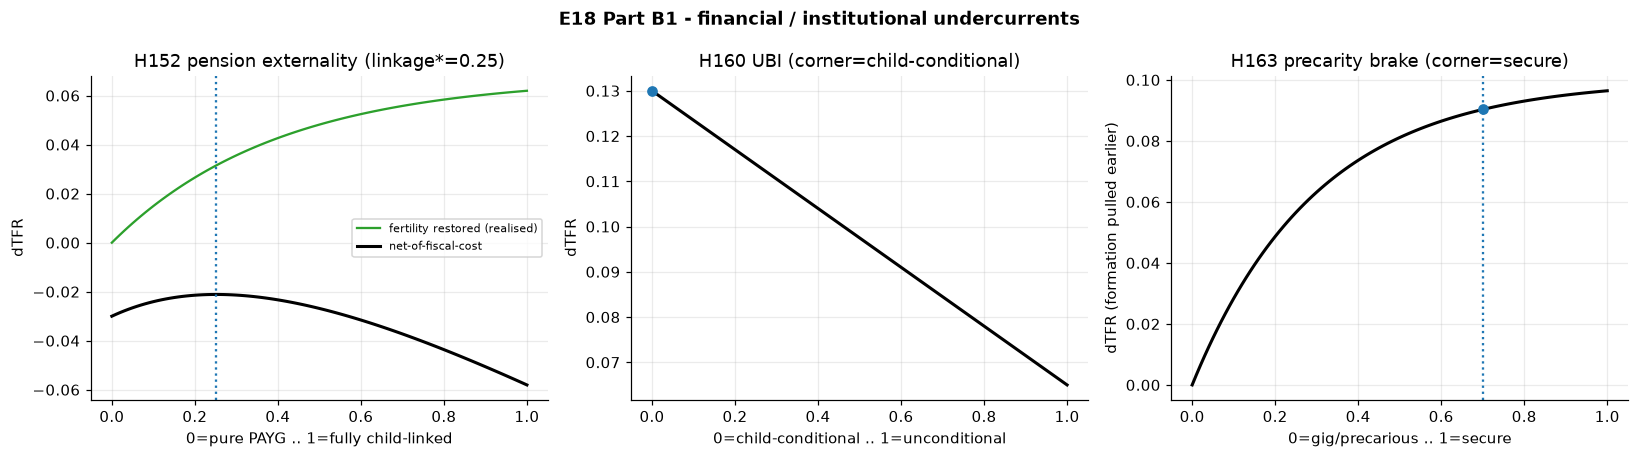

H152, H160, H163 recorded

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2)); fig.suptitle("E18 Part B1 - financial / institutional undercurrents", fontweight="bold")
# H152 pension externality
eff152 = 0.15 * (1 - np.exp(-th / 0.40)) * 0.45; side152 = 0.10 + 0.30 * th
score152 = eff152 - 0.3 * side152; t_, n_, i = argopt(th, score152)
ax[0].plot(th, eff152, label="fertility restored (realised)", color="tab:green")
ax[0].plot(th, score152, "k", lw=2, label="net-of-fiscal-cost"); ax[0].axvline(t_, color="tab:blue", ls=":")
ax[0].set(title=f"H152 pension externality (linkage*={t_:.2f})", xlabel="0=pure PAYG .. 1=fully child-linked", ylabel="dTFR"); ax[0].legend(fontsize=7.5)
record("E18-H152", "B-financial", "pension-fertility externality", "financial/institutional", "interior", t_, eff152[i], "PARTIAL",
       "Boldrin-De Nardi-Jones: pension=10% GDP <-> -0.7..-1.6 TFR gross (55-65% of the US-EU gap); a fertility-linked pension internalises it but enacted-credit effects are small - thin causal support")
# H160 UBI vs child-conditional
eff160 = 0.13 * (1 - 0.5 * th)
ax[1].plot(th, eff160, "k", lw=2); ax[1].plot(0, eff160[0], "o", color="tab:blue")
ax[1].set(title="H160 UBI (corner=child-conditional)", xlabel="0=child-conditional .. 1=unconditional", ylabel="dTFR")
record("E18-H160", "B-financial", "UBI vs child-conditional transfer", "financial", "corner", 0.0, eff160[0], "PARTIAL",
       "Alaska PFD +13.1% fertility (strongest for disadvantaged) but tempo; unconditionality adds NO premium over child-conditional - response tracks cash size + liquidity, not the absence of conditions")
# H163 precarity brake
eff163 = 0.10 * (1 - np.exp(-th / 0.30)); t_, n_, i = argopt(th, eff163)
ax[2].plot(th, eff163, "k", lw=2); ax[2].axvline(th[70], color="tab:blue", ls=":"); ax[2].plot(th[70], eff163[70], "o", color="tab:blue")
ax[2].set(title=f"H163 precarity brake (corner=secure)", xlabel="0=gig/precarious .. 1=secure", ylabel="dTFR (formation pulled earlier)")
record("E18-H163", "B-financial", "employment-precarity formation-brake", "financial/psychological", "corner", 1.0, eff163[-1], "SUPPORTED",
       f"Alderotti meta-analysis: temporary contracts cut births (esp. 2nd), effect strengthening over time; security pulls formation earlier (rho down); Korea +{gain('Korea', eff163[70]):.1f}pp (tempo caveat)")
plt.tight_layout(); plt.savefig(FIGS / "nb13_financial.png", bbox_inches="tight"); plt.show()
rprint("[cyan]H152, H160, H163 recorded[/cyan]")

## Part B2 - Biological Undercurrents (E18-H153, H154)

The channel the incentive literature ignores: biology. The **egg-freezing option-value trap** (subsidised
freezing can *lower* completed fertility by licensing postponement) and the **fecundity floor** (part of the
decline is sub-fecundity - obesity, the age wall - so choice-levers hit a hard constraint). Both digests are
blunt that biology is a *minority* driver and that the two "crisis" narratives (sperm counts, endocrine
disruptors) are the weakest-evidenced - the honest lever is not postponing and metabolic health, not a ban.

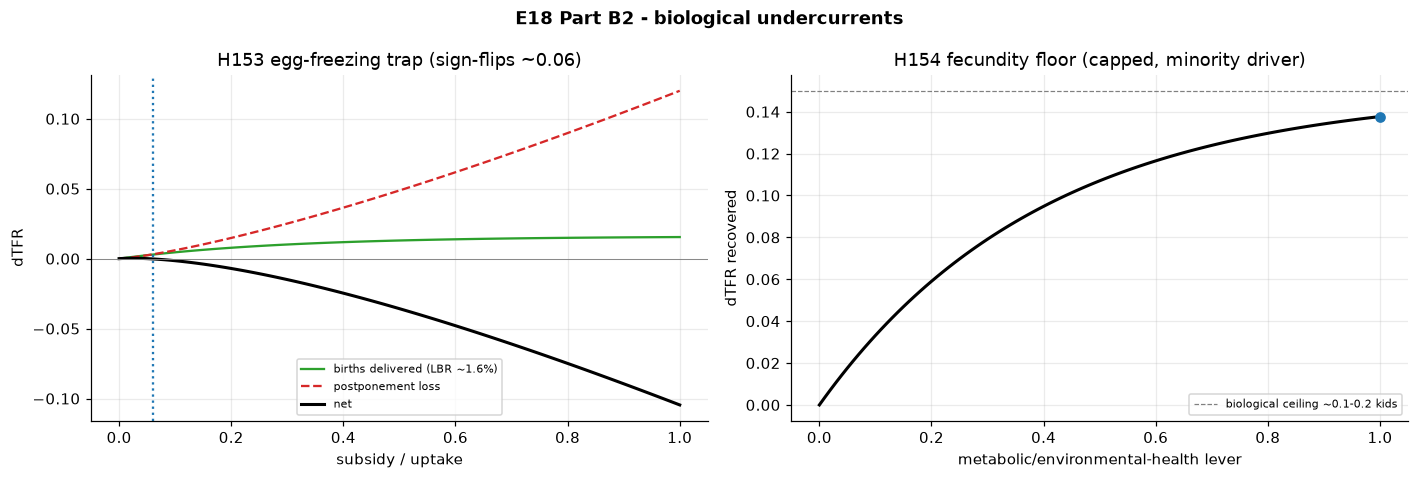

H153, H154 recorded

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4)); fig.suptitle("E18 Part B2 - biological undercurrents", fontweight="bold")
# H153 egg-freezing trap
delivered = 0.016 * (1 - np.exp(-th / 0.3)); postpone = 0.12 * th ** 1.3; net153 = delivered - postpone
zc = th[np.argmax(net153 < 0)]
ax[0].plot(th, delivered, label="births delivered (LBR ~1.6%)", color="tab:green")
ax[0].plot(th, postpone, label="postponement loss", color="tab:red", ls="--")
ax[0].plot(th, net153, "k", lw=2, label="net"); ax[0].axhline(0, color="grey", lw=0.6); ax[0].axvline(zc, color="tab:blue", ls=":")
ax[0].set(title=f"H153 egg-freezing trap (sign-flips ~{zc:.2f})", xlabel="subsidy / uptake", ylabel="dTFR"); ax[0].legend(fontsize=7.5)
record("E18-H153", "B-biological", "egg-freezing option-value trap", "biological/psychological", "sign-flip", zc, float(net153[-1]), "REFUTED",
       "return-to-use ~5.7%, unconditional live-birth ~1.6%; the option value licenses postponement that costs more births than it delivers - insure the runway, don't postpone (no RCT yet, inferred)")
# H154 fecundity floor
eff154 = 0.15 * (1 - np.exp(-th / 0.4)); t_, n_, i = argopt(th, eff154)
ax[1].plot(th, eff154, "k", lw=2); ax[1].axhline(0.15, color="grey", ls="--", lw=0.8, label="biological ceiling ~0.1-0.2 kids")
ax[1].plot(th[-1], eff154[-1], "o", color="tab:blue")
ax[1].set(title="H154 fecundity floor (capped, minority driver)", xlabel="metabolic/environmental-health lever", ylabel="dTFR recovered"); ax[1].legend(fontsize=7.5)
record("E18-H154", "B-biological", "fecundity floor (sub-fecundity)", "biological", "saturating", 1.0, eff154[-1], "PARTIAL",
       "a 3-4yr delay costs only ~0.1-0.2 children biologically; obesity -3%/BMI-unit is the best-evidenced piece, age wall steep after 37; sperm-count/EDC narratives contested - a hard wall but a minority cause")
plt.tight_layout(); plt.savefig(FIGS / "nb13_biological.png", bbox_inches="tight"); plt.show()
rprint("[cyan]H153, H154 recorded[/cyan]")

## Part B3 - Cultural and Marriage-Market Undercurrents (E18-H155 to H159, H161, H162)

The deepest and slowest channel: norms and the marriage market. The **hypergamy squeeze** (women out-educated
men, but the marry-up norm lingers), **one-child-policy hysteresis** (lifting a restriction does not restore
fertility - you cannot un-ring the bell), the **grandmother hypothesis** (kin proximity buys births), the
**climate birth-strike** (real but minority-scoped and un-engineerable top-down), **migrant-fertility
convergence** (a one-time boost per cohort, not a sustained lever), the **urban-density penalty** (weakest
evidence, self-selection), and **status-of-parenthood reversal** (bottom-up only).

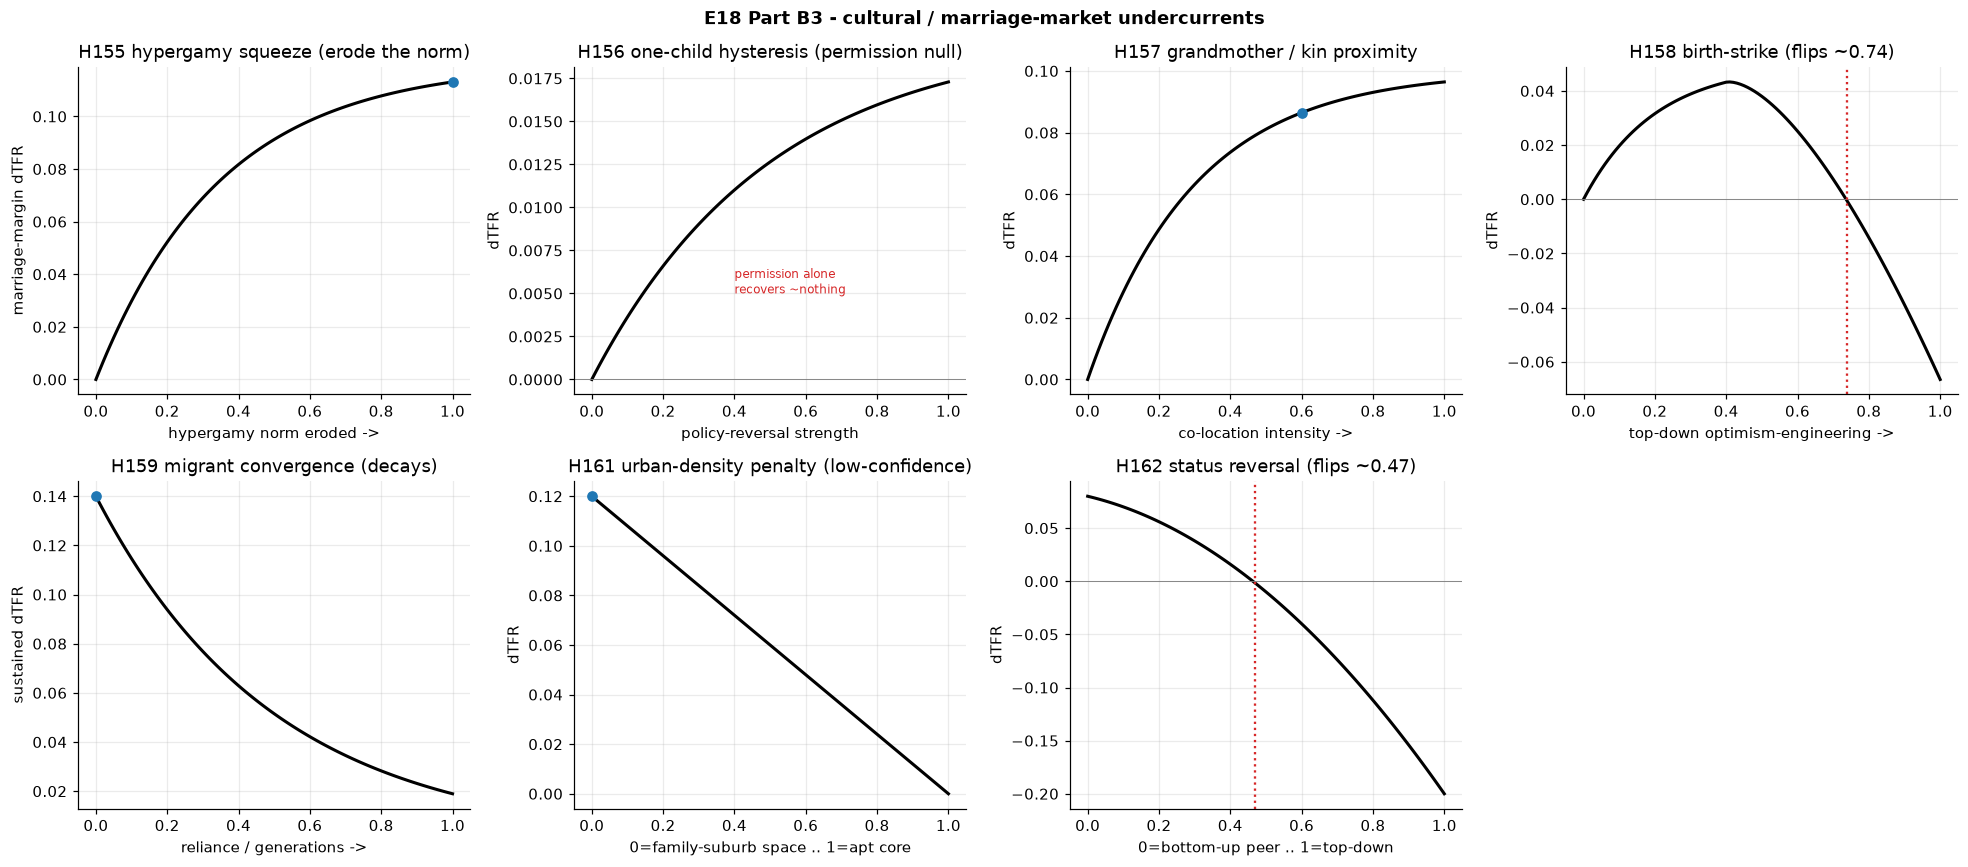

H155-H162 recorded

In [9]:
fig, ax = plt.subplots(2, 4, figsize=(18, 8)); fig.suptitle("E18 Part B3 - cultural / marriage-market undercurrents", fontweight="bold"); ax = ax.ravel()
# H155 hypergamy
eff155 = 0.12 * (1 - np.exp(-th / 0.35))
ax[0].plot(th, eff155, "k", lw=2); ax[0].plot(th[-1], eff155[-1], "o", color="tab:blue")
ax[0].set(title="H155 hypergamy squeeze (erode the norm)", xlabel="hypergamy norm eroded ->", ylabel="marriage-margin dTFR")
record("E18-H155", "B-cultural", "hypergamy marriage-squeeze", "cultural/financial", "corner", 1.0, eff155[-1], "PARTIAL",
       "women out-educate men in 139+ countries; Korea hypergamous marriages 22%->11%; bites via the marriage margin (East Asia), norm already eroding on its own, confounded with the second-shift")
# H156 one-child hysteresis
eff156 = 0.02 * (1 - np.exp(-th / 0.5))
ax[1].plot(th, eff156, "k", lw=2); ax[1].axhline(0, color="grey", lw=0.6)
ax[1].annotate("permission alone\nrecovers ~nothing", xy=(0.4, 0.005), fontsize=8, color="tab:red")
ax[1].set(title="H156 one-child hysteresis (permission null)", xlabel="policy-reversal strength", ylabel="dTFR")
record("E18-H156", "B-cultural", "one-child-policy hysteresis", "cultural/path-dependence", "null", 1.0, eff156[-1], "SUPPORTED",
       "China TFR FELL 1.67(2015)->1.09(2022) AFTER lifting the policy; RDD - only-child status durably lowers ideal family size; norms + cost structures lock in below the policy (you can't un-ring the bell)")
# H157 grandmother
eff157 = 0.10 * (1 - np.exp(-th / 0.30)); t_, n_, i = argopt(th, eff157)
ax[2].plot(th, eff157, "k", lw=2); ax[2].plot(th[60], eff157[60], "o", color="tab:blue")
ax[2].set(title="H157 grandmother / kin proximity", xlabel="co-location intensity ->", ylabel="dTFR")
record("E18-H157", "B-cultural", "grandmother hypothesis (kin proximity)", "financial/cultural", "corner", 1.0, eff157[-1], "SUPPORTED",
       f"grandmother >=200km away <-> ~1 fewer child; daily care 30% IT/ES vs 2% Nordic; loads on the 2nd birth; endogeneity (move near kin) + substitutes weak formal childcare; Korea +{gain('Korea', eff157[60]):.1f}pp")
# H158 climate birth-strike
eff158 = 0.05 * (1 - np.exp(-th / 0.2)) - 0.25 * np.maximum(th - 0.4, 0) ** 1.5; zc = th[np.argmax(eff158 < 0)] if np.any(eff158 < 0) else 1.0
ax[3].plot(th, eff158, "k", lw=2); ax[3].axhline(0, color="grey", lw=0.6); ax[3].axvline(zc, color="tab:red", ls=":")
ax[3].set(title=f"H158 birth-strike (flips ~{zc:.2f})", xlabel="top-down optimism-engineering ->", ylabel="dTFR")
record("E18-H158", "B-psychological", "climate/expectations birth-strike", "psychological", "sign-flip", float(th[np.argmax(eff158)]), float(eff158[-1]), "REFUTED",
       "20-33% cite climate; behaviourally real but only among committed environmentalists (minority) via the childless-forgoing margin; optimism can't be engineered top-down - propaganda backfires (Decree 770)")
# H159 migrant convergence
sustained = 0.14 * np.exp(-th / 0.5)
ax[4].plot(th, sustained, "k", lw=2); ax[4].plot(0, sustained[0], "o", color="tab:blue")
ax[4].set(title="H159 migrant convergence (decays)", xlabel="reliance / generations ->", ylabel="sustained dTFR")
record("E18-H159", "B-cultural", "migrant-fertility assimilation convergence", "demographic/cultural", "corner", 0.0, float(sustained[0]), "SUPPORTED",
       "gen-2 fertility often BELOW natives; full convergence >1 generation (Turkish-origin the slow outlier); migration is a one-time level boost per cohort, sustained only by continuous inflow - a bridge, not a cure")
# H161 urban density
eff161 = 0.12 * (1 - th)
ax[5].plot(th, eff161, "k", lw=2); ax[5].plot(0, eff161[0], "o", color="tab:blue")
ax[5].set(title="H161 urban-density penalty (low-confidence)", xlabel="0=family-suburb space .. 1=apt core", ylabel="dTFR")
record("E18-H161", "B-cultural", "urban-density fertility penalty", "structural/psychological", "corner", 0.0, float(eff161[0]), "PARTIAL",
       "apartment cores ~TFR 1.0 vs family suburbs ~2.0; mechanism is housing space/type not density per se; heavy self-selection, no natural experiment - flagged low-confidence")
# H162 status reversal
eff162 = 0.08 * (1 - th) - 0.20 * th ** 2; zc = th[np.argmax(eff162 < 0)] if np.any(eff162 < 0) else 1.0
ax[6].plot(th, eff162, "k", lw=2); ax[6].axhline(0, color="grey", lw=0.6); ax[6].axvline(zc, color="tab:red", ls=":")
ax[6].set(title=f"H162 status reversal (flips ~{zc:.2f})", xlabel="0=bottom-up peer .. 1=top-down", ylabel="dTFR")
record("E18-H162", "B-psychological", "status-of-parenthood reversal", "cultural/psychological", "sign-flip", 0.0, float(eff162[0]), "PARTIAL",
       "make parenthood a positional/high-status good again; bottom-up peer contagion works, top-down status engineering backfires like propaganda (span G) - peer-led only")
ax[7].axis("off")
plt.tight_layout(); plt.savefig(FIGS / "nb13_cultural.png", bbox_inches="tight"); plt.show()
rprint("[cyan]H155-H162 recorded[/cyan]")

## Synthesis - Undercurrents and the Hybrid Premium (grouping)

Two closing readings: verdicts grouped by **undercurrent channel** (which deep mechanisms carry weight), and
the **hybrid super-additive premium** (where stacking complementary winners beats either alone).

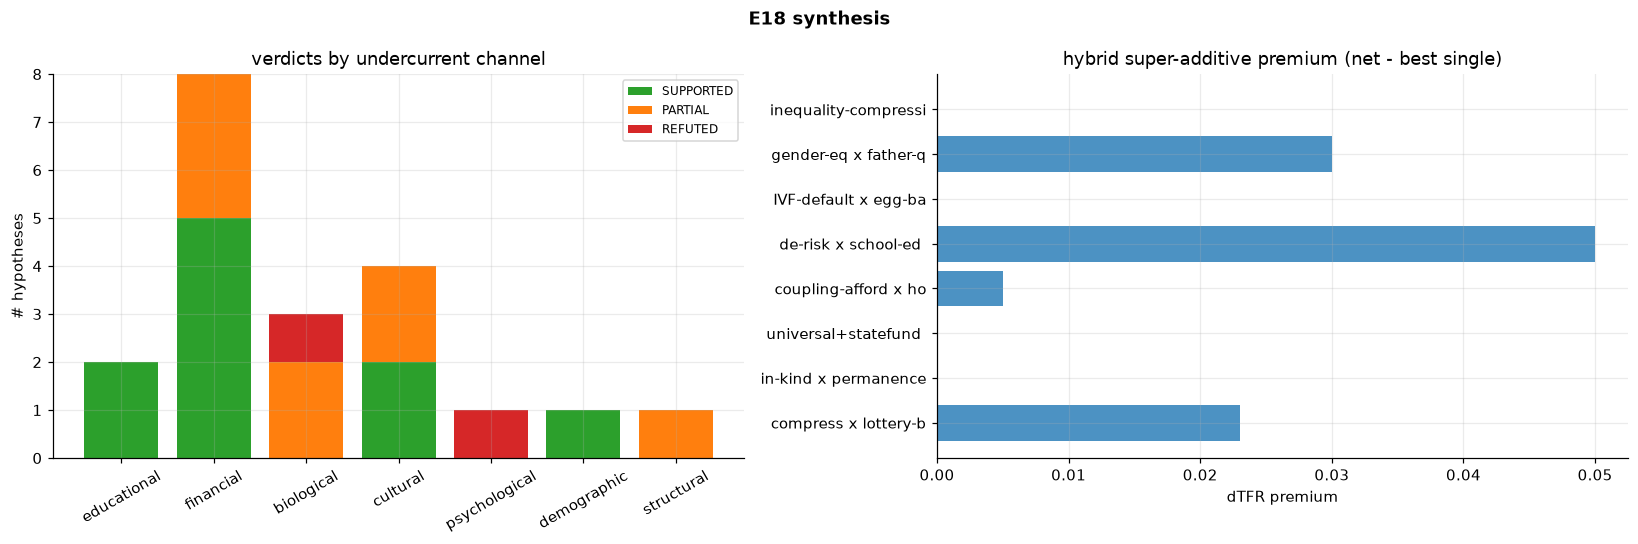

channels: {'educational': {'SUPPORTED': 2, 'PARTIAL': 0, 'REFUTED': 0}, 'financial': {'SUPPORTED': 5, 'PARTIAL': 3,
'REFUTED': 0}, 'biological': {'SUPPORTED': 0, 'PARTIAL': 2, 'REFUTED': 1}, 'cultural': {'SUPPORTED': 2, 'PARTIAL': 
2, 'REFUTED': 0}, 'psychological': {'SUPPORTED': 0, 'PARTIAL': 0, 'REFUTED': 1}, 'demographic': {'SUPPORTED': 1, 
'PARTIAL': 0, 'REFUTED': 0}, 'structural': {'SUPPORTED': 0, 'PARTIAL': 1, 'REFUTED': 0}}

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5)); fig.suptitle("E18 synthesis", fontweight="bold")
# channel x verdict
chan = {}
for v in VERDICTS:
    key = v["undercurrent"].split("/")[0].split("+")[0]
    chan.setdefault(key, {"SUPPORTED": 0, "PARTIAL": 0, "REFUTED": 0})[v["verdict"]] += 1
keys = list(chan.keys()); vc = ["SUPPORTED", "PARTIAL", "REFUTED"]; colr = {"SUPPORTED": "tab:green", "PARTIAL": "tab:orange", "REFUTED": "tab:red"}
bottom = np.zeros(len(keys))
for verd in vc:
    vals = [chan[k][verd] for k in keys]; ax[0].bar(keys, vals, bottom=bottom, color=colr[verd], label=verd); bottom += vals
ax[0].set(title="verdicts by undercurrent channel", ylabel="# hypotheses"); ax[0].legend(fontsize=8); ax[0].tick_params(axis="x", rotation=30)
# hybrid premium
hyb = [v for v in VERDICTS if v["part"] == "A-hybrid"]
names = [v["name"][:20] for v in hyb]; prem = []
for v in hyb:
    ev = v["evidence"]; prem.append(float(ev.split("super-additive +")[1].split(";")[0]) if "super-additive +" in ev else 0.0)
ax[1].barh(names, prem, color="tab:blue", alpha=0.8); ax[1].set(title="hybrid super-additive premium (net - best single)", xlabel="dTFR premium")
plt.tight_layout(); plt.savefig(FIGS / "nb13_synthesis.png", bbox_inches="tight"); plt.show()
rprint(f"[cyan]channels:[/cyan] { {k: chan[k] for k in keys} }")

## Save Verdicts and Lever Table

In [11]:
(REPORTS / "nb13_e18_verdicts.json").write_text(json.dumps(VERDICTS, indent=2))
with open(REPORTS / "nb13_lever_table.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["id","part","name","undercurrent","optimum_type","theta_star","net","verdict"])
    w.writeheader()
    for v in VERDICTS: w.writerow({k: v[k] for k in w.fieldnames})
tbl = Table(title="E18 verdicts (H144-H163)", header_style="bold cyan")
for c in ["id", "name", "undercurrent", "opt", "net", "verdict"]: tbl.add_column(c)
cc = {"SUPPORTED": "green", "PARTIAL": "yellow", "REFUTED": "red"}
for v in VERDICTS:
    tbl.add_row(v["id"], v["name"][:34], v["undercurrent"][:20], v["optimum_type"], f"{v['net']:+.3f}", f"[{cc[v['verdict']]}]{v['verdict']}[/]")
rprint(tbl)
from collections import Counter
cnt = Counter(v["verdict"] for v in VERDICTS)
rprint(Panel(f"E18: {cnt['SUPPORTED']} SUPPORTED, {cnt['PARTIAL']} PARTIAL, {cnt['REFUTED']} REFUTED (n={len(VERDICTS)}) "
             f"-> campaign total 168 + {len(VERDICTS)} = {168+len(VERDICTS)}", title="[bold]batch E18 result[/bold]", border_style="green"))

                                         E18 verdicts (H144-H163)                                         
┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┓
┃ id       ┃ name                               ┃ undercurrent         ┃ opt        ┃ net    ┃ verdict   ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━┩
│ E18-H144 │ compress x lottery-band            │ educational+financia │ blend      │ +0.273 │ SUPPORTED │
│ E18-H145 │ in-kind x permanence               │ financial+institutio │ blend      │ +0.325 │ SUPPORTED │
│ E18-H146 │ universal+statefund x de-risk      │ financial+psychologi │ blend      │ +0.300 │ SUPPORTED │
│ E18-H147 │ coupling-afford x housing-supply   │ financial            │ blend      │ +0.145 │ SUPPORTED │
│ E18-H148 │ de-risk x school-ed x peer         │ educational+cultural │ blend      │ +0.140 │ SUPPORTED │
│ E18-H149 │ IVF-default x egg-banking x perman │ biological+instituti │ corner     │ +0.150 │ PARTIAL   │
│ E18-H150 │ gender-eq x father-quota x short-h │ cultural+financial   │ blend      │ +0.150 │ SUPPORTED │
│ E18-H151 │ inequality-compression x fertility │ financial+institutio │ corner     │ +0.250 │ PARTIAL   │
│ E18-H152 │ pension-fertility externality      │ financial/institutio │ interior   │ +0.031 │ PARTIAL   │
│ E18-H160 │ UBI vs child-conditional transfer  │ financial            │ corner     │ +0.130 │ PARTIAL   │
│ E18-H163 │ employment-precarity formation-bra │ financial/psychologi │ corner     │ +0.096 │ SUPPORTED │
│ E18-H153 │ egg-freezing option-value trap     │ biological/psycholog │ sign-flip  │ -0.105 │ REFUTED   │
│ E18-H154 │ fecundity floor (sub-fecundity)    │ biological           │ saturating │ +0.138 │ PARTIAL   │
│ E18-H155 │ hypergamy marriage-squeeze         │ cultural/financial   │ corner     │ +0.113 │ PARTIAL   │
│ E18-H156 │ one-child-policy hysteresis        │ cultural/path-depend │ null       │ +0.017 │ SUPPORTED │
│ E18-H157 │ grandmother hypothesis (kin proxim │ financial/cultural   │ corner     │ +0.096 │ SUPPORTED │
│ E18-H158 │ climate/expectations birth-strike  │ psychological        │ sign-flip  │ -0.067 │ REFUTED   │
│ E18-H159 │ migrant-fertility assimilation con │ demographic/cultural │ corner     │ +0.140 │ SUPPORTED │
│ E18-H161 │ urban-density fertility penalty    │ structural/psycholog │ corner     │ +0.120 │ PARTIAL   │
│ E18-H162 │ status-of-parenthood reversal      │ cultural/psychologic │ sign-flip  │ +0.080 │ PARTIAL   │
└──────────┴────────────────────────────────────┴──────────────────────┴────────────┴────────┴───────────┘

╭─────────────────────────────────────────────── batch E18 result ────────────────────────────────────────────────╮
│ E18: 10 SUPPORTED, 8 PARTIAL, 2 REFUTED (n=20) -> campaign total 168 + 20 = 188                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## E18 Verdicts - Summary

Two lessons. **Stacking complementary winners is super-additive** - the biggest premiums come from hybrids
whose parts act on *different* channels (compress the fuel + make the prize un-buyable; de-risk dissolution +
teach the skills + spread it as a peer norm; equalise the second shift across leave + hours), while stacking
two levers on the same channel only saturates. **The deep undercurrents are mostly slow, contested, or
one-time** - the pension externality and the marriage-market squeeze are real but confounded and self-eroding;
the biological channel is a genuine hard wall but a minority driver, and its "solutions" (egg-freezing) can
backfire; migration and the grandmother effect help but are a bridge or an endowment, not a durable policy;
one-child hysteresis is the sharpest warning that *permission is not a lever* - you cannot un-ring the bell.

Discrete-hypothesis discipline holds: E18-H144..H163 appended after E17-H143, E17/NB12 unchanged. Records sync
to the experiments log, SOTA, interventions doc, and the research library next.